In [230]:
!pip install pymc
# arch
# yfinance

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 562.8/562.8 kB 1.5 MB/s  0:00:0036m-:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 842.2 kB/s  0:00:01ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 93.4 kB/s  0:00:16 eta 0:00:02m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 188.0 kB/s  0:00:07 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 574.0 kB/s  0:00:05 eta 0:00:01
  Attempting uninstall: cachetools━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  2/14 [h5py]
    Found existing installation: cachetools 7.0.5━━━━━━━━━━━━━  2/14 [h5py]
    Uninstalling cachetools-7.0.5:━━━━━━━━━━━━━━━━━━━━━━━━━━━━  2/14 [h5py]
      Successfully uninstalled cachetools-7.0.5━━━━━━━━━━━━━━━  2/14 [h5py]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14/14 [pymc]2m13/14 [pymc]sor]


In [ ]:
import gpytorch as gp, sklearn as sk, numpy as np, matplotlib.pyplot as plt, arch, pandas as pd
from statsmodels.graphics.tsaplots import plot_acf
import pymc as pm
import arviz as az
import numpy as np
import matplotlib.pyplot as plt
import kagglehub
import pandas as pd
import os
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from tqdm import tqdm
import statsmodels.api as sm
from scipy.stats import norm

import warnings
warnings.filterwarnings('ignore')

import pymc as pm
import arviz as az
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, ExpSineSquared, ConstantKernel as C
rng = np.random.RandomState(17)

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ExpSineSquared, ConstantKernel, RationalQuadratic, Matern, DotProduct


## 1

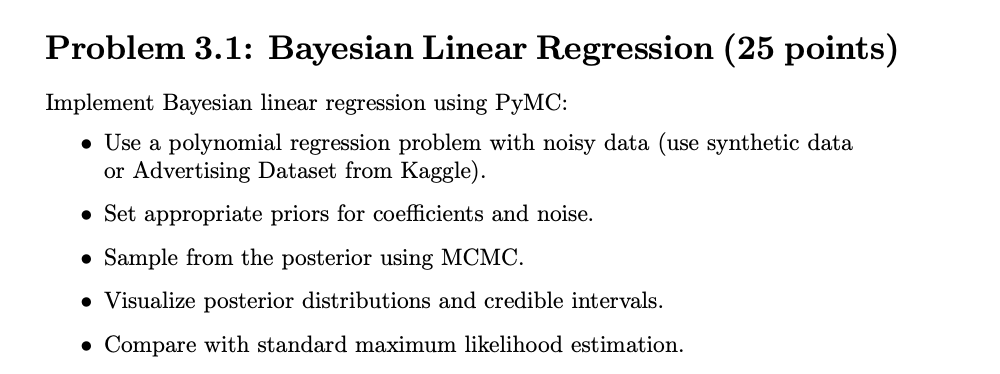

We generate synthetic data from a quadratic (polynomial degree 2) model:


y = B_0 + B_1 x + B_2 x^2 + $\epsilon$


where:
- $\left(B_0 = 5\right), \left(B_1 = 25\right), \left(B_2 = -10\right)$
- Noise: $\left(\epsilon \sim N(0, 10)\right)$


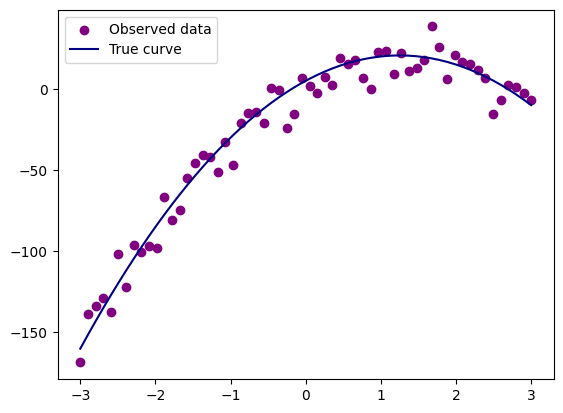

In [ ]:
np.random.seed(47)

B_0_true = 5
B_1_true = 25
B_2_true = -10
sigma_true = 10

N = 60
x = np.linspace(-3, 3, N)
y_true = B_0_true + B_1_true * x + B_2_true * x**2
y = y_true + np.random.normal(0, sigma_true, size=N)

plt.scatter(x, y, label="Observed data", c = "purple")
plt.plot(x, y_true, color="navy", label="True curve")
plt.legend()
plt.show()

We define a Bayesian regression model using PyMC:
Model Components

Priors:
$$
B_0, B_1, B_2 \sim \mathcal{N}(0, 10)
$$

$$
\sigma \sim \text{HalfNormal}(5)
$$

### Likelihood

$$
y_i \sim \mathcal{N}(B_0 + B_1 x_i + B_2 x_i^2, \sigma)
$$


In [ ]:
with pm.Model() as model:

    # Priors
    B_0 = pm.Normal("B_0", mu=0, sigma=10)
    B_1 = pm.Normal("B_1", mu=0, sigma=10)
    B_2 = pm.Normal("B_2", mu=0, sigma=10)
    sigma = pm.HalfNormal("sigma", sigma=5)

    # Expected value
    mu = B_0 + B_1 * x + B_2 * x**2

    # Likelihood
    y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y)

    trace = pm.sample(2000, tune=1000, chains=4, random_seed=47)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [B_0, B_1, B_2, sigma]


C:\Users\testo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\
Python313\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 181 seconds.


We use NUTS to sample from the posterior:

- 4 chains
- 2000 samples
- 1000 tuning steps

Convergence diagnostics:

- $\hat{R} \approx 1.0$ → good convergence
- High ESS → stable estimates

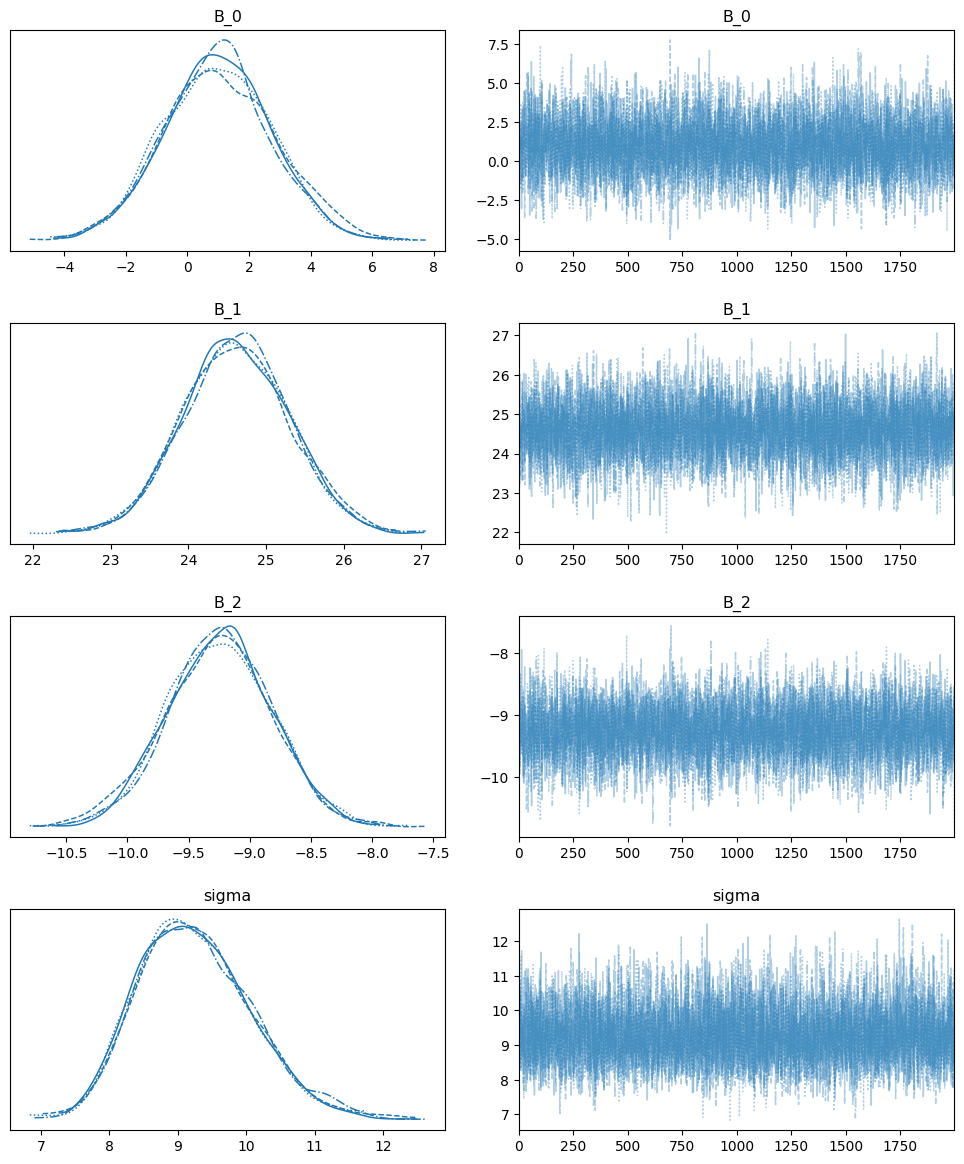

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
B_0,0.988,1.764,-2.331,4.269,0.024,0.021,5587.0,5186.0,1.0
B_1,24.614,0.686,23.320,25.895,0.008,0.008,7270.0,5689.0,1.0
B_2,-9.246,0.428,-10.093,-8.478,0.006,0.005,5484.0,5233.0,1.0
sigma,9.252,0.826,7.786,10.799,0.010,0.009,7384.0,6010.0,1.0


In [ ]:
az.plot_trace(trace, figsize=(10, 12))
plt.tight_layout(pad=2.0)
plt.show()

az.summary(trace)

We compute 94% Highest Density Intervals (HDI):

Example:

$$
B_1 \in [23.3, 25.9]
$$

Interpretation:

There is a 94% probability that $B_1$ lies in this interval.

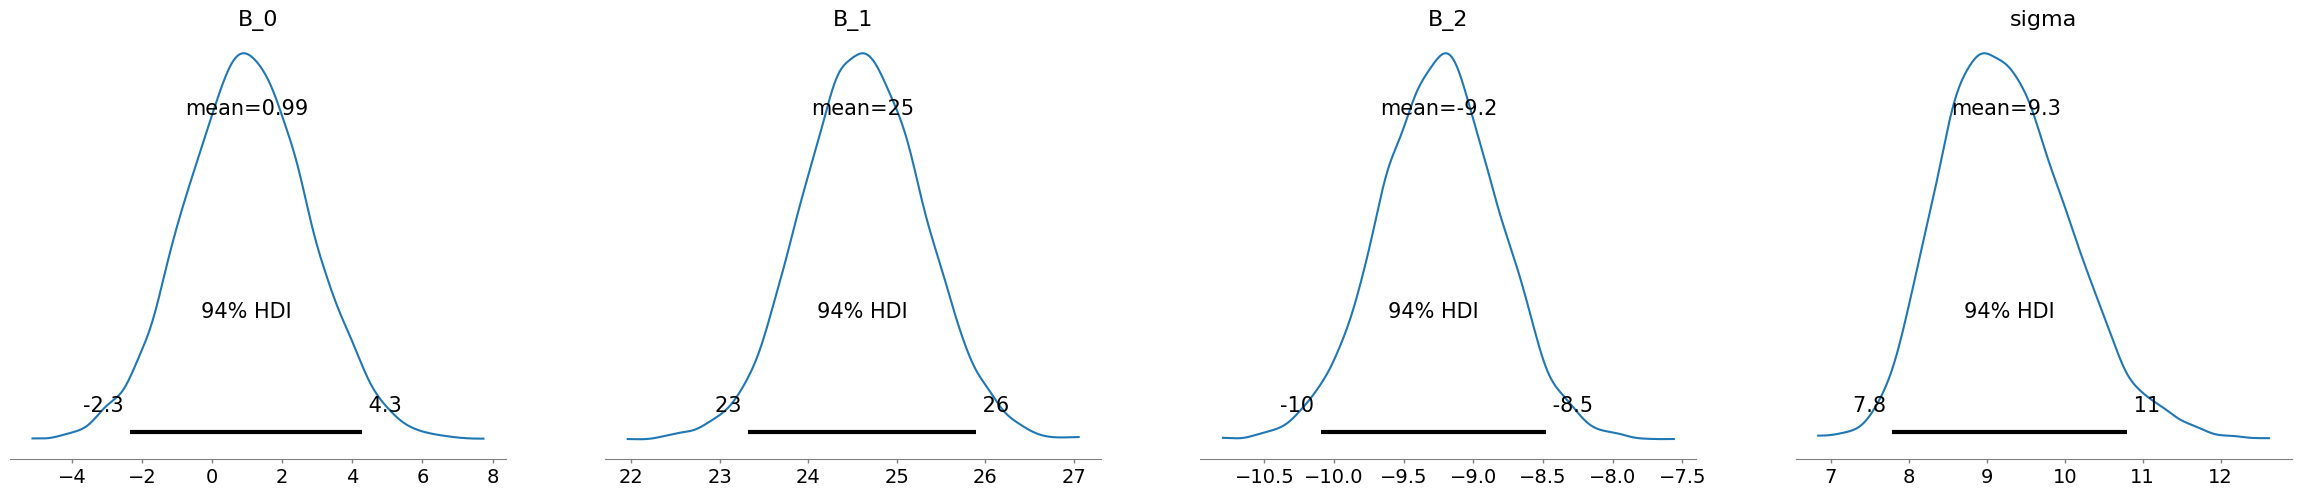

In [ ]:
az.plot_posterior(trace, hdi_prob=0.94)
plt.show()

- MLE gives a single best-fit curve
- Bayesian gives a **distribution over curves**


C:\Users\testo\AppData\Local\Temp\ipykernel_18060\3838097407.py:18: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  y_hdi = az.hdi(y_preds, hdi_prob=0.94)


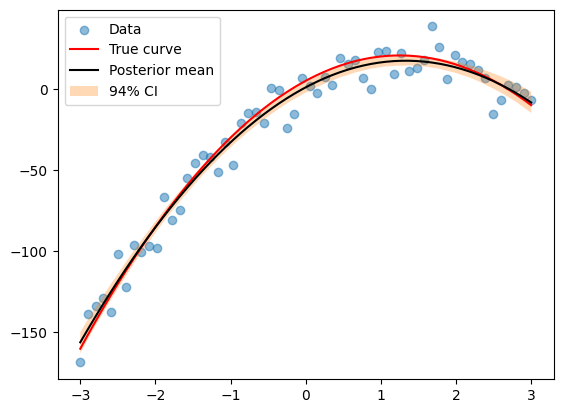

In [ ]:
posterior = trace.posterior

B_0_s = posterior["B_0"].values.flatten()
B_1_s = posterior["B_1"].values.flatten()
B_2_s = posterior["B_2"].values.flatten()


x_grid = np.linspace(-3, 3, 60)

y_preds = np.array([
    b0 + b1 * x_grid + b2 * x_grid**2
    for b0, b1, b2 in zip(B_0_s, B_1_s, B_2_s)
])


y_mean = y_preds.mean(axis=0)
y_hdi = az.hdi(y_preds, hdi_prob=0.94)

# Plot
plt.scatter(x, y, alpha=0.5, label="Data")
plt.plot(x_grid, y_true, color="red", label="True curve")
plt.plot(x_grid, y_mean, color="black", label="Posterior mean")

plt.fill_between(x_grid, y_hdi[:, 0], y_hdi[:, 1], alpha=0.3, label="94% CI")
plt.legend()
plt.show()


$$
y^{new} \sim p(y \mid x, \text{data})
$$

This includes:

- Parameter uncertainty
- Observation noise



Sampling: [y_obs]


C:\Users\testo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\
Python313\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

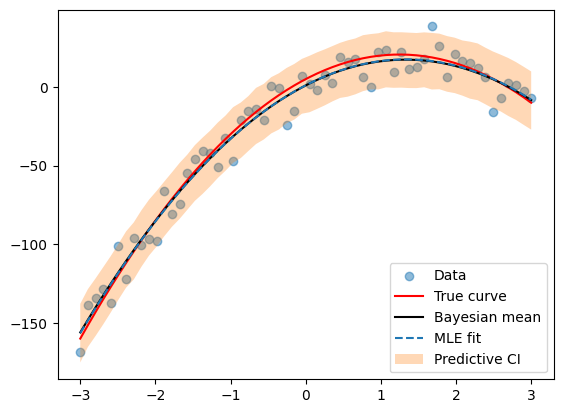

In [ ]:
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(x.reshape(-1, 1))

model_mle = LinearRegression()
model_mle.fit(X_poly, y)

y_mle = model_mle.predict(poly.transform(x_grid.reshape(-1, 1)))


with model:
    posterior_pred = pm.sample_posterior_predictive(trace)

y_pred_samples = posterior_pred.posterior_predictive["y_obs"].values

y_pred_hdi = az.hdi(y_pred_samples, hdi_prob=0.94)



plt.scatter(x, y, alpha=0.5, label="Data")
plt.plot(x_grid, y_true, color="red", label="True curve")
plt.plot(x_grid, y_mean, color="black", label="Bayesian mean")
plt.plot(x_grid, y_mle, linestyle="--", label="MLE fit")
plt.fill_between(x, y_pred_hdi[:, 0], y_pred_hdi[:, 1], alpha=0.3, label="Predictive CI")


plt.legend()
plt.show()

## 2

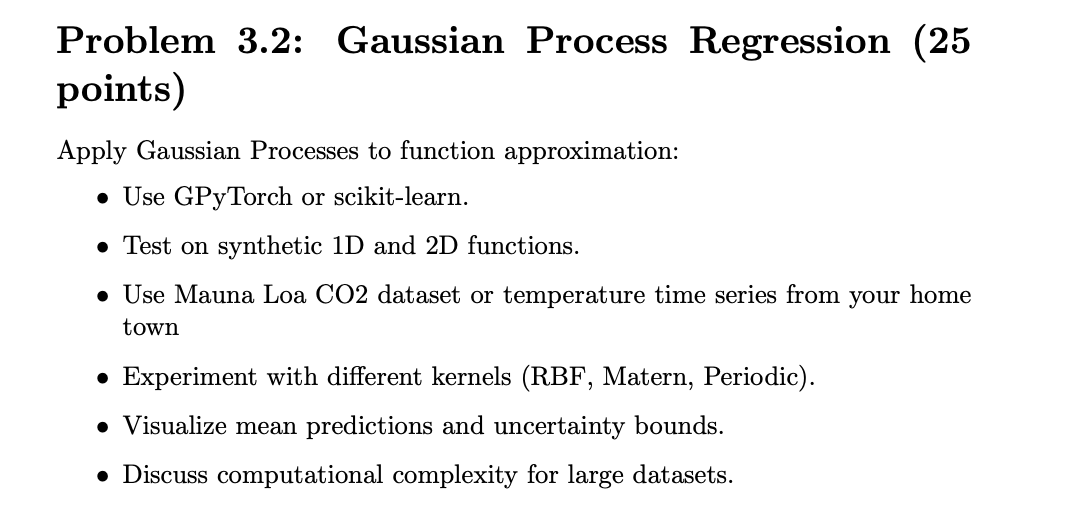

Processing 1D Synthetic Data...


/Users/marysia/Desktop/applied/ml_project/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


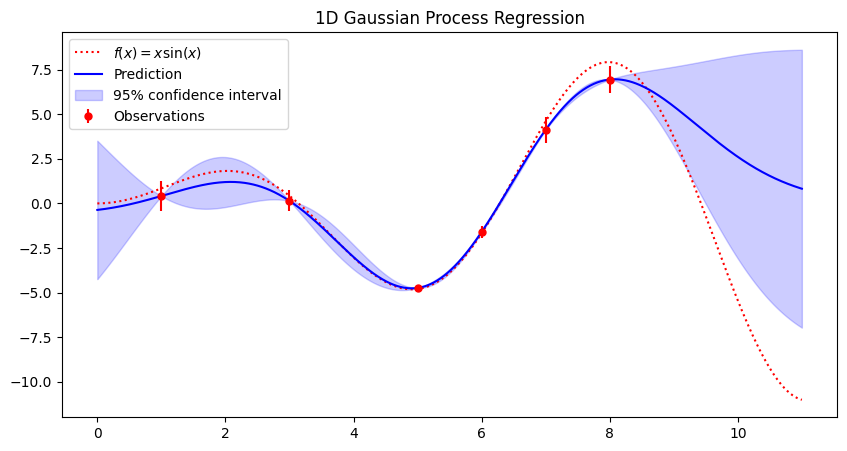

In [270]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, ExpSineSquared, ConstantKernel as C
rng = np.random.RandomState(17)

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ExpSineSquared, ConstantKernel, RationalQuadratic, Matern

print("Processing 1D Synthetic Data...")
def f_1d(x):
    return x * np.sin(x)

X_train_1d = np.atleast_2d([1., 3., 5., 6., 7., 8.]).T
y_train_1d = f_1d(X_train_1d).ravel()
dy = np.random.random(y_train_1d.shape)
noise = np.random.normal(0, dy)
y_train_1d += noise

# RBF for smoothness, WhiteKernel to estimate noise
kernel_1d = C(1.0) * RBF(length_scale=1.0, length_scale_bounds=(1e-1, 10.0)) + WhiteKernel(noise_level=1)
gp_1d = GaussianProcessRegressor(kernel=kernel_1d, n_restarts_optimizer=10)
gp_1d.fit(X_train_1d, y_train_1d)

X_grid_1d = np.linspace(0, 11, 1000).reshape(-1, 1)
y_pred_1d, sigma_1d = gp_1d.predict(X_grid_1d, return_std=True)

plt.figure(figsize=(10, 5))
plt.plot(X_grid_1d, f_1d(X_grid_1d), 'r:', label=r'$f(x) = x \sin(x)$')
plt.errorbar(X_train_1d.ravel(), y_train_1d, dy, fmt='r.', markersize=10, label='Observations')
plt.plot(X_grid_1d, y_pred_1d, 'b-', label='Prediction')
plt.fill_between(X_grid_1d.ravel(), y_pred_1d - 1.96 * sigma_1d, y_pred_1d + 1.96 * sigma_1d, alpha=0.2, color='blue', label='95% confidence interval')
plt.title("1D Gaussian Process Regression")
plt.legend()
plt.show()


Processing 2D Synthetic Data...


/Users/marysia/Desktop/applied/ml_project/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 10 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


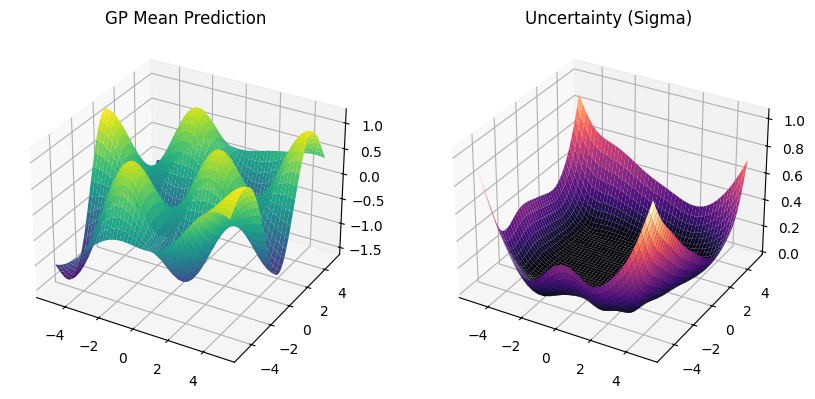

In [249]:
print("Processing 2D Synthetic Data...")
def f_2d(x):
    return np.sin(x[:, 0]) * np.cos(x[:, 1])

X_train_2d = np.random.uniform(-3, 3, (50, 2))
y_train_2d = f_2d(X_train_2d)

kernel_2d = C(1.0) * RBF(1.0)
gp_2d = GaussianProcessRegressor(kernel=kernel_2d, n_restarts_optimizer=10)
gp_2d.fit(X_train_2d, y_train_2d)

res = 50
x1, x2 = np.meshgrid(np.linspace(-5, 5, res), np.linspace(-5, 5, res))
X_grid_2d = np.vstack([x1.ravel(), x2.ravel()]).T
y_pred_2d, sigma_2d = gp_2d.predict(X_grid_2d, return_std=True)

fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(121, projection='3d')
ax.plot_surface(x1, x2, y_pred_2d.reshape(res, res), cmap='viridis')
ax.set_title("GP Mean Prediction")
ax = fig.add_subplot(122, projection='3d')
ax.plot_surface(x1, x2, sigma_2d.reshape(res, res), cmap='magma')
ax.set_title("Uncertainty (Sigma)")
plt.show()

In [194]:
data = pd.read_csv("/Users/marysia/Desktop/applied/ml/apl_math/co2_mm_mlo.csv")
data

,year,month,decimal date,average,deseasonalized,ndays,sdev,unc
0,1958,3,1958.2027,315.71,314.44,-1,-9.99,-0.99
1,1958,4,1958.2877,317.45,315.16,-1,-9.99,-0.99
2,1958,5,1958.3699,317.51,314.69,-1,-9.99,-0.99
3,1958,6,1958.4548,317.27,315.15,-1,-9.99,-0.99
4,1958,7,1958.5370,315.87,315.20,-1,-9.99,-0.99
...,...,...,...,...,...,...,...,...
811,2025,10,2025.7917,424.87,428.10,19,0.32,0.14
812,2025,11,2025.8750,426.46,428.43,20,0.69,0.30
813,2025,12,2025.9583,427.49,428.21,24,0.31,0.12
814,2026,1,2026.0417,428.62,428.37,25,0.69,0.26


Processing Mauna Loa CO2 Data...


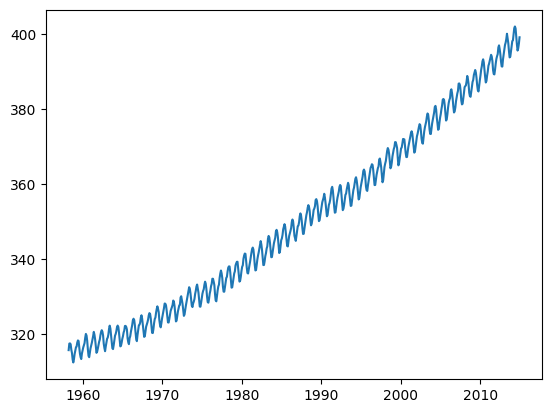

In [260]:
X = data['decimal date'].values.reshape(-1, 1)
y = data['average'].values

train_mask = X.ravel() <= 2015
X_train, y_train = X[train_mask], y[train_mask]
X_test, y_test = X[~train_mask], y[~train_mask]
plt.plot(X_train, y_train, label="Training data")

Percentage of test points in 95% interval: 96.27%


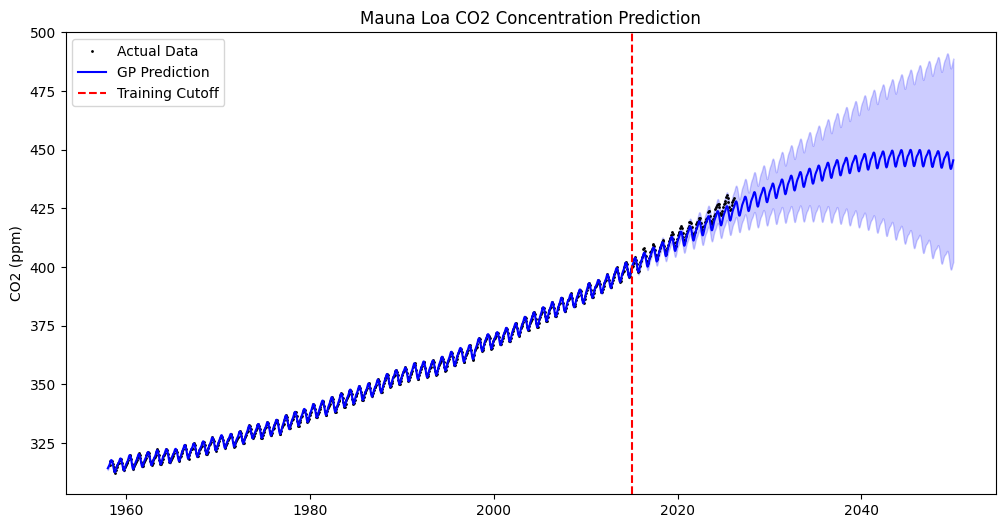

In [271]:
# Complex Kernel for CO2 (Trend + Seasonality + Noise)
k1 = 50.0**2 * RBF(length_scale=50.0)  # Long term trend
k2 = 2.0**2 * RBF(length_scale=100.0) * ExpSineSquared(length_scale=1.0, periodicity=1.0)  # Seasonal
k3 = 0.5**2 * RationalQuadratic(length_scale=1.0, alpha=1.0)  # Irregularities
kernel_co2 = k1 + k2 + k3 + WhiteKernel(noise_level=0.1)

gp_co2 = GaussianProcessRegressor(kernel=kernel_co2, n_restarts_optimizer=20, normalize_y=True)
gp_co2.fit(X_train, y_train)

# Predict until 2050
X_grid_co2 = np.linspace(1958, 2050, 2000).reshape(-1, 1)
y_pred_co2, sigma_co2 = gp_co2.predict(X_grid_co2, return_std=True)

# Evaluate
points_inside = np.sum((y_test >= (gp_co2.predict(X_test) - 1.96 * gp_co2.predict(X_test, return_std=True)[1])) & 
                       (y_test <= (gp_co2.predict(X_test) + 1.96 * gp_co2.predict(X_test, return_std=True)[1])))
print(f"Percentage of test points in 95% interval: {points_inside/len(y_test)*100:.2f}%")

# Visualize CO2
plt.figure(figsize=(12, 6))
plt.plot(X, y, 'k.', markersize=2, label='Actual Data')
plt.plot(X_grid_co2, y_pred_co2, 'b-', label='GP Prediction')
plt.fill_between(X_grid_co2.ravel(), y_pred_co2 - 2*sigma_co2, y_pred_co2 + 2*sigma_co2, color='blue', alpha=0.2)
plt.axvline(2015, color='red', linestyle='--', label='Training Cutoff')
plt.title("Mauna Loa CO2 Concentration Prediction")
plt.ylabel("CO2 (ppm)")
plt.legend()
plt.show()

## 3

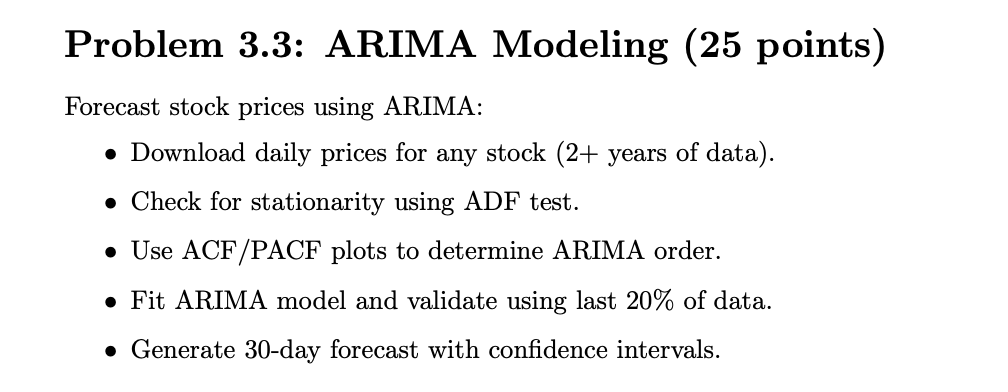

Download dataset of apple stock prices and show few first rows

In [ ]:
path = kagglehub.dataset_download("varpit94/apple-stock-data-updated-till-22jun2021")

file_path = os.path.join(path, "AAPL.csv")

df = pd.read_csv(file_path)

print(df.head())

             Date        Open        High         Low       Close   Adj Close  \
10404  2022-03-18  160.509995  164.479996  159.759995  163.979996  163.979996   
10405  2022-03-21  163.509995  166.350006  163.009995  165.380005  165.380005   
10406  2022-03-22  165.509995  169.419998  164.910004  168.820007  168.820007   
10407  2022-03-23  167.990005  172.639999  167.649994  170.210007  170.210007   
10408  2022-03-24  171.059998  174.139999  170.210007  174.070007  174.070007   

          Volume  
10404  123351200  
10405   95811400  
10406   81532000  
10407   98062700  
10408   90018700  


we get some info about data like types and number of Nulls of features

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10409 entries, 0 to 10408
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       10409 non-null  object 
 1   Open       10409 non-null  float64
 2   High       10409 non-null  float64
 3   Low        10409 non-null  float64
 4   Close      10409 non-null  float64
 5   Adj Close  10409 non-null  float64
 6   Volume     10409 non-null  int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 569.4+ KB


In [ ]:
df.isna().any()

Date         False
Open         False
High         False
Low          False
Close        False
Adj Close    False
Volume       False
dtype: bool

we transorm feature "Date" form object type into datetime. Later we change that feature into index of rows and cut data from a very distant past. Then we plot a chart of daily close price  

In [ ]:
df["Date"] = pd.to_datetime(df["Date"])
df = df.set_index("Date").sort_index()

cut_date = "2016-01-01"
split_date = "2021-01-01"

df= df.loc[cut_date:].copy()

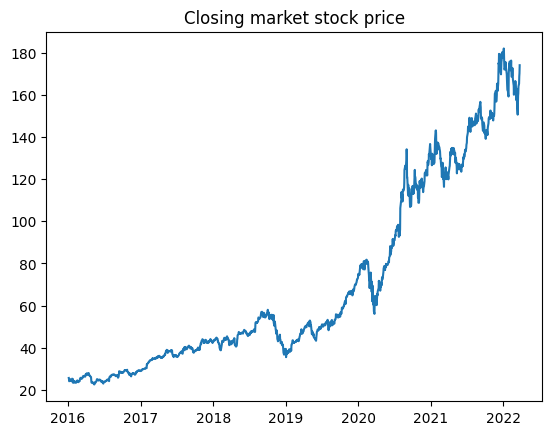

In [ ]:
plt.plot(df["Close"])
plt.title("Closing market stock price")
df["ready"] = df["Close"]

we see some exponential incrising so we use log tranformation

Text(0.5, 1.0, 'Logarithmic closing market stock price')

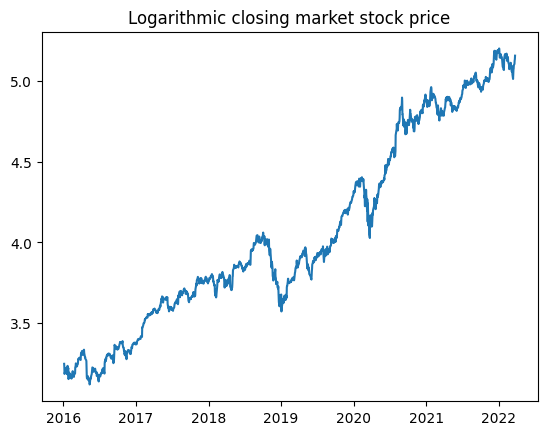

In [ ]:
close = df["Close"].copy()
df["ready"] = np.log(close)
plt.plot(df["ready"])

plt.title("Logarithmic closing market stock price")

We add the data after a single differentiation to df as return and also ew plot them

Text(0.5, 1.0, 'returns')

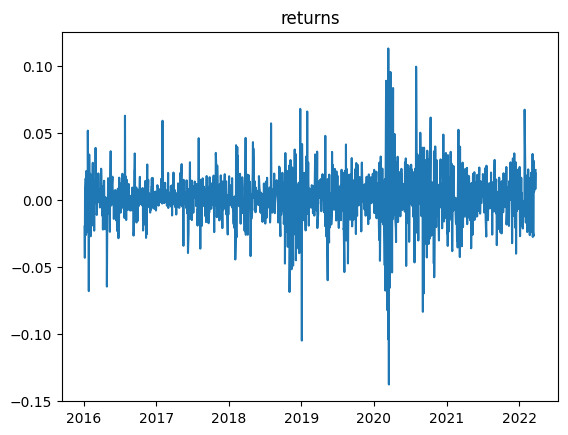

In [ ]:
df["return"] = (df["ready"]).diff()
df = df.dropna()
plt.plot(df["return"])
plt.title("returns")

we define function stationarity_tests with two test ADF and KPSS to analise if returns are likely stacionra or not and there is needed second differencing. Both tests results are consistent and say that returns are stacionary

In [ ]:
def stationarity_tests(series, name="series"):
    print(f"\n===== Stationarity tests for {name} =====")
    adf_stat, adf_p, _, _, _, _ = adfuller(series)

    print(f"\nADF Test:\nStatistic: {adf_stat:.6f}\np-value:   {adf_p:.6f}")
    if adf_p < 0.05:
        print(" === Reject H0 (unit root) -> likely STATIONARY ===")
    else:
        print(" === Fail to reject H0 -> NON-stationary ===")


    kpss_stat, kpss_p, _, _ = kpss(series, regression="c", nlags="auto")

    print(f"\nKPSS Test:\nStatistic: {kpss_stat:.6f}\np-value:   {kpss_p:.6f}")

    if kpss_p < 0.05:
        print(" === Reject H0 (stationarity) -> NON-stationary ===")
    else:
        print(" === Fail to reject H0 -> likely STATIONARY ===\n\n")

In [ ]:
stationarity_tests(df["return"], "return")


===== Stationarity tests for return =====

ADF Test:
Statistic: -10.402122
p-value:   0.000000
 === Reject H0 (unit root) ⇒ likely STATIONARY ===

KPSS Test:
Statistic: 0.098138
p-value:   0.100000
 === Fail to reject H0 ⇒ likely STATIONARY ===




In [ ]:
df_return_mean_m = df["return"].rolling(30).mean()

df_return_vol_m = df["return"].rolling(30).std()

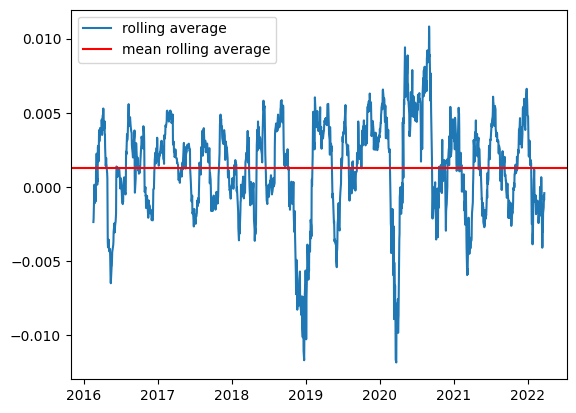

In [ ]:
plt.plot(df_return_mean_m, label="rolling average")
plt.axhline(df_return_mean_m.mean(),color = "red", label="mean rolling average")
plt.legend()

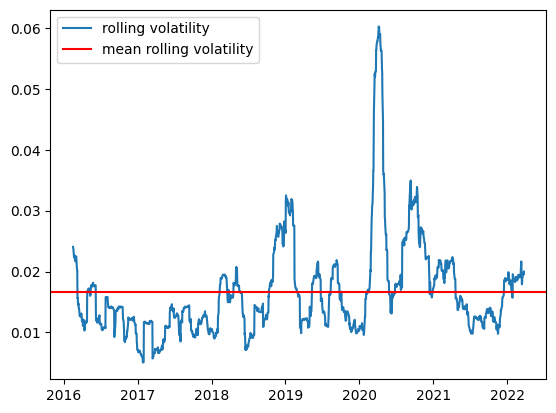

In [ ]:
plt.plot(df_return_vol_m, label="rolling volatility")
plt.axhline(df_return_vol_m.mean(),color = "red", label="mean rolling volatility")
plt.legend()

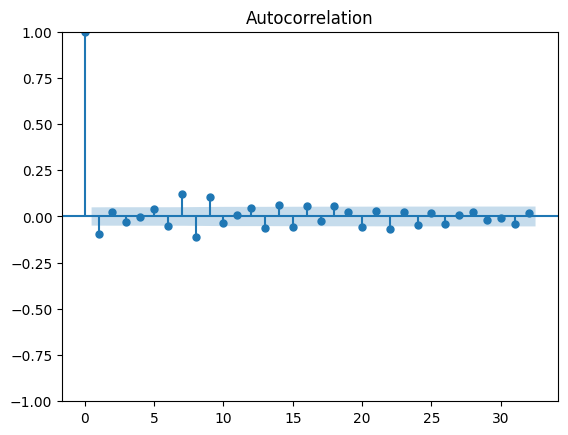

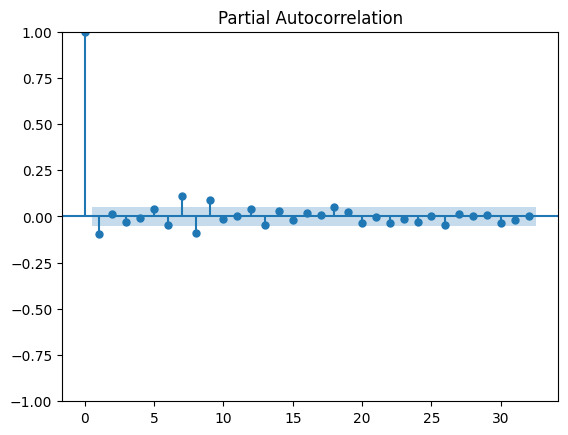

In [ ]:
plot_acf(df["return"])
plot_pacf(df["return"])
plt.show()

we split data into test (after 2021-01-01) and training (before 2021-01-01)sets

In [ ]:
df_train= df.loc[:split_date].copy()
df_test= df.loc[split_date:].copy()


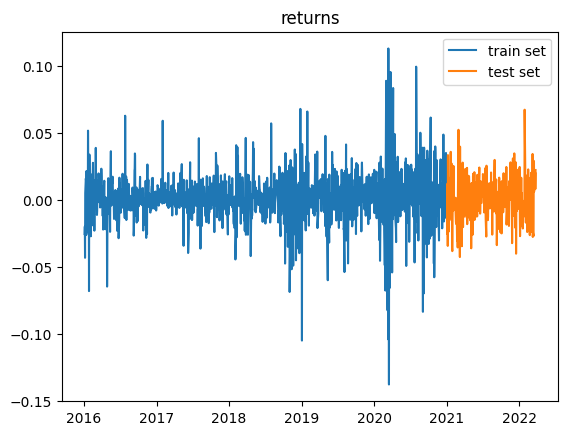

In [ ]:
plt.plot(df_train["return"], label = "train set")
plt.plot(df_test["return"], label = "test set")
plt.title("returns")
plt.legend()

In [ ]:
# span =  30

# df_train["trend"] = df_train["ready"].ewm(span=span, adjust=False).mean()
# df_train["detrended"] = df_train["ready"] - df_train["trend"]

# df_test["trend"] = df_test["ready"].ewm(span=span, adjust=False).mean()
# df_test["detrended"] = df_test["ready"] - df_test["trend"]

# df_test["ready"] = df_test["detrended"]
# df_train["ready"] = df_train["detrended"]

# plt.plot(df_train["detrended"])
# plt.plot(df_test["detrended"])

we chose ARIMA(4, 1, 4) as model with best AIC score

In [ ]:
Y_train = df_train["ready"]
orders = [(i,1,k) for i in range(5) for k in range(5)]
results = []
for order in tqdm(orders):
    model = ARIMA(Y_train, order = order)
    result = model.fit()
    results.append([order, result.aic])

100%|██████████| 25/25 [00:06<00:00,  3.77it/s]


In [ ]:
df_results = pd.DataFrame(results, columns=["order", "AIC"])
df_results = df_results.sort_values("AIC")
df_results.head()


,order,AIC
24,"(4, 1, 4)",-6414.335623
19,"(3, 1, 4)",-6406.745267
5,"(1, 1, 0)",-6398.868858
1,"(0, 1, 1)",-6398.037713
6,"(1, 1, 1)",-6397.461483


fiting all time set to model and predict all future steps at once doesn't bring well results so as a next step we tried predicting one future step based on model fitted in moving window. New results are a little bit better but still not following the data well, so we calculate confident interval to check if it still in this and fortunetuly yes.

In [ ]:
order = df_results["order"][24]
model = ARIMA(Y_train, order=order)
model_fit = model.fit()

pred = model_fit.forecast(steps=len(df_test))

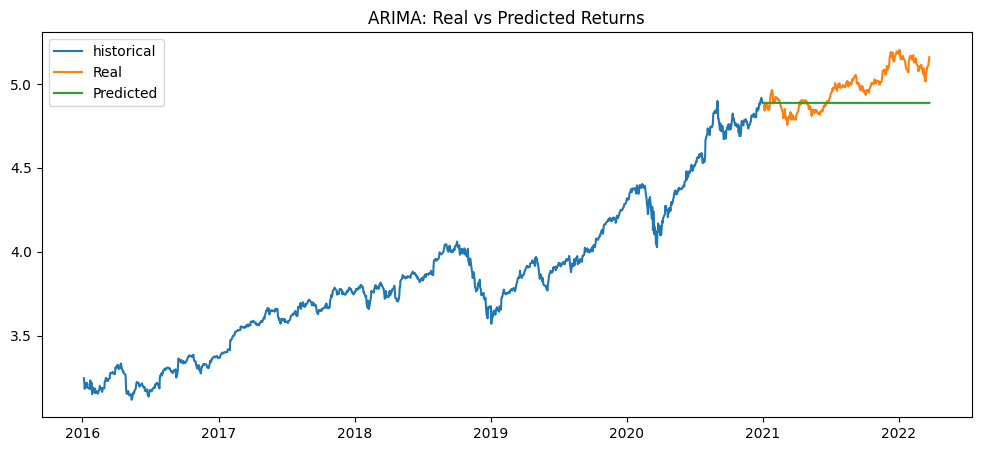

In [ ]:

plt.figure(figsize=(12,5))

plt.plot(df_train["ready"], label="historical")
plt.plot(df_test["ready"], label="Real")
plt.plot(df_test.index, pred, label="Predicted")

plt.title("ARIMA: Real vs Predicted Returns")
plt.legend()
plt.show()

In [ ]:
window = 360
train_series = Y_train.copy()

train_preds = np.zeros(len(train_series)-window)

for i in tqdm(range(window, len(train_series))):
    y_window = train_series.iloc[i-window:i]
    
    model = ARIMA(y_window, order=order)
    model_fit = model.fit()

    train_preds[i-window] = model_fit.forecast(steps=1)

100%|██████████| 898/898 [11:19<00:00,  1.32it/s]


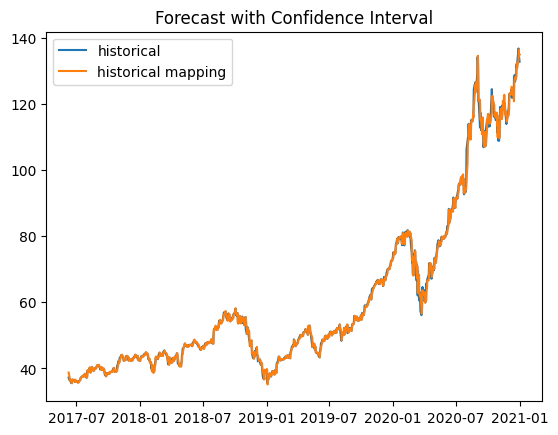

In [ ]:
plt.plot(np.exp(Y_train[window:]), label='historical')
plt.plot(Y_train[window:].index, np.exp(train_preds), label="historical mapping")

plt.legend()
plt.title("Forecast with Confidence Interval")
plt.show()

In [ ]:
test_len = len(df_test)
history = list(train_series.iloc[-window:])

train_preds_future = np.zeros(test_len)
# ci_lower_list = np.zeros(test_len)
# ci_upper_list = np.zeros(test_len)


for i in tqdm(range(test_len)):
    model = ARIMA(history, order=order)
    model_fit = model.fit()
    
    forecast_res = model_fit.get_forecast(steps=1)

    pred = forecast_res.predicted_mean[0]
    # ci = forecast_res.conf_int()

    train_preds_future[i] = pred
    # ci_lower_list[i] = ci[0][0]
    # ci_upper_list[i] = ci[0][1]
    history.append(pred)
    history.pop(0)

100%|██████████| 309/309 [03:14<00:00,  1.59it/s]


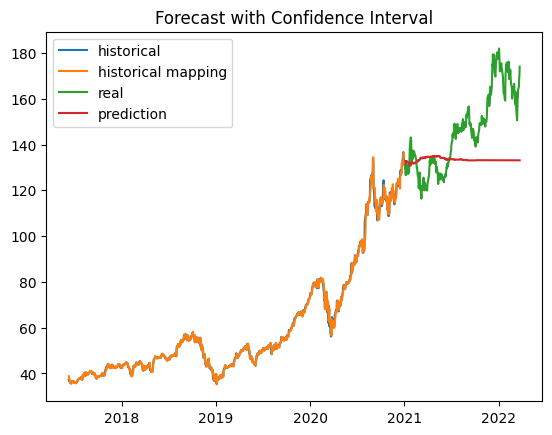

In [ ]:
plt.plot(np.exp(Y_train[window:]), label='historical')
plt.plot(Y_train[window:].index, np.exp(train_preds), label="historical mapping")

plt.plot(df_test["Close"], label="real")
plt.plot(df_test.index, np.exp(train_preds_future), label="prediction")
plt.legend()
plt.title("Forecast with Confidence Interval")
plt.show()

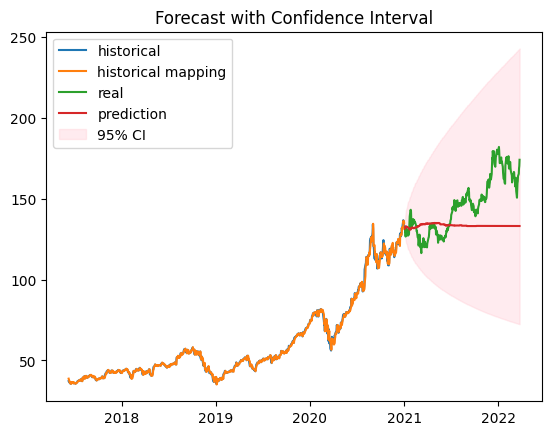

In [ ]:
plt.plot(np.exp(Y_train[window:]), label='historical')
plt.plot(Y_train[window:].index, np.exp(train_preds), label="historical mapping")

plt.plot(df_test["Close"], label="real")
plt.plot(df_test.index, np.exp(train_preds_future), label="prediction")


model = ARIMA(Y_train, order=order) #Y_train[-20:] ładne
model_fit = model.fit()
forecast_res = model_fit.get_forecast(steps=test_len)
ci = forecast_res.conf_int()


plt.fill_between(
    df_test.index,
    np.exp(ci.iloc[:, 0]),
    np.exp(ci.iloc[:, 1]),
    color='pink',
    alpha=0.3,
    label="95% CI"
)

plt.legend()
plt.title("Forecast with Confidence Interval")
plt.show()

Tries of impruving prediction

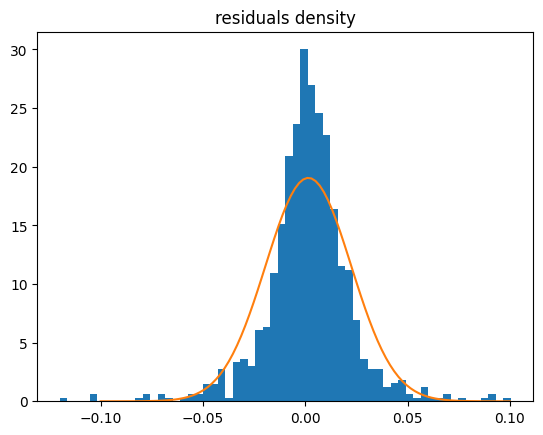

In [ ]:
true_values = train_series.iloc[window:]
residuals = true_values - train_preds
plt.hist(residuals, bins=60, density=True)
x = np.linspace(-0.1, 0.1, 100)
mu = np.mean(residuals)
sigma = np.std(residuals)
pdf = norm.pdf(x, loc=mu, scale=sigma)
plt.title("residuals density")
plt.plot(x, pdf)


In [ ]:
window = 1080
train_series = Y_train.copy()

train_preds = np.zeros(len(train_series)-window)

for i in tqdm(range(window, len(train_series))):
    y_window = train_series.iloc[i-window:i]
    
    model = ARIMA(y_window, order=order)
    model_fit = model.fit()

    train_preds[i-window] = model_fit.forecast(steps=1)

  4%|▍         | 8/178 [00:09<03:36,  1.27s/it]

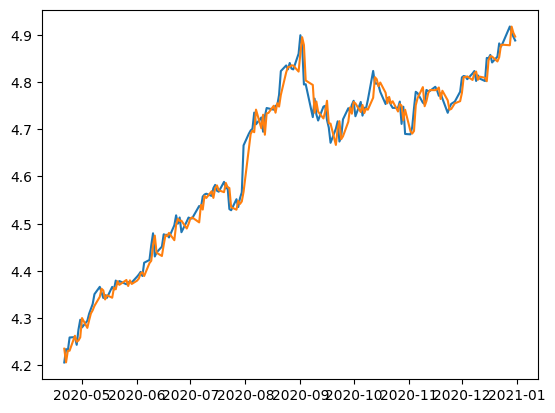

In [ ]:
plt.plot(Y_train[window:])
plt.plot(Y_train[window:].index,train_preds)

In [ ]:
test_len = len(df_test)
history = list(train_series.iloc[-window:])

train_preds_future = np.zeros(test_len)

for i in tqdm(range(test_len)):
    model = ARIMA(history, order=order)
    model_fit = model.fit()
    
    pred = model_fit.forecast(steps=1)[0]

    train_preds_future[i] = pred
    history.append(pred)
    history.pop(0)

100%|██████████| 309/309 [06:02<00:00,  1.17s/it]


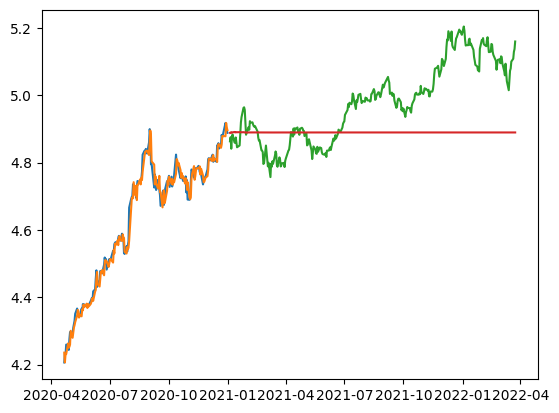

In [ ]:
plt.plot(Y_train[window:])
plt.plot(Y_train[window:].index,train_preds)

plt.plot(df_test["ready"])
plt.plot(df_test.index, train_preds_future)

In [ ]:
test_len = len(df_test)
window = 60
history = list(train_series.iloc[-window:])

train_preds_future = np.zeros(test_len)

for i in tqdm(range(test_len)):
    model = ARIMA(history, order=order)
    model_fit = model.fit()
    
    pred = model_fit.forecast(steps=1)[0]

    train_preds_future[i] = pred
    history.append(pred)
    history.pop(0)

100%|██████████| 309/309 [01:54<00:00,  2.70it/s]


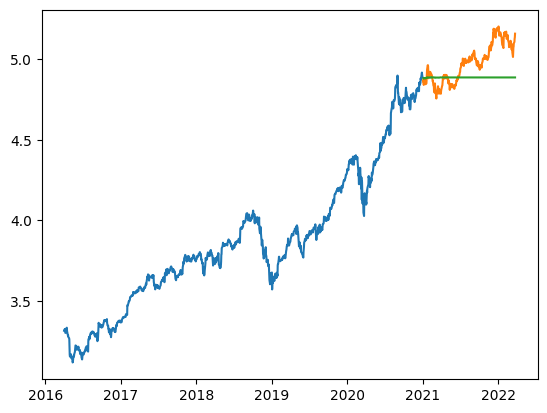

In [ ]:
plt.plot(Y_train[window:])
# plt.plot(Y_train[window:].index,train_preds)

plt.plot(df_test["ready"])
plt.plot(df_test.index, train_preds_future)

forecasting more steps also didn't help

In [ ]:
test_len = 50
window = 101
history = list(train_series.iloc[-window:-100])

train_preds_future = []

for i in tqdm(range(test_len)):
    model = ARIMA(history, order=order)
    model_fit = model.fit()
    
    pred = model_fit.forecast(steps=2)

    train_preds_future.extend(pred)
    history.extend(train_series.iloc[-100+i:i-98])
    history = history[2:]

100%|██████████| 50/50 [00:00<00:00, 69.55it/s]


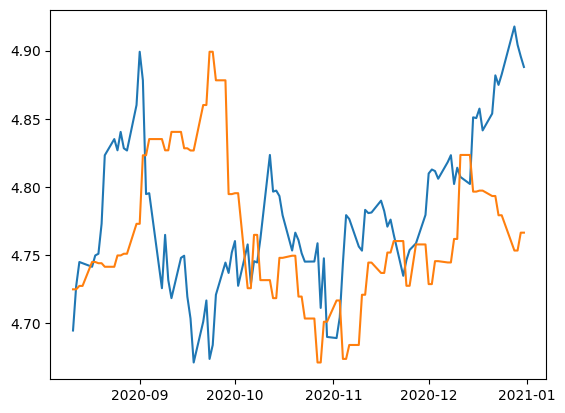

In [ ]:
plt.plot(Y_train[-window+1:])
plt.plot(Y_train[-window+1:].index, train_preds_future)

## 4

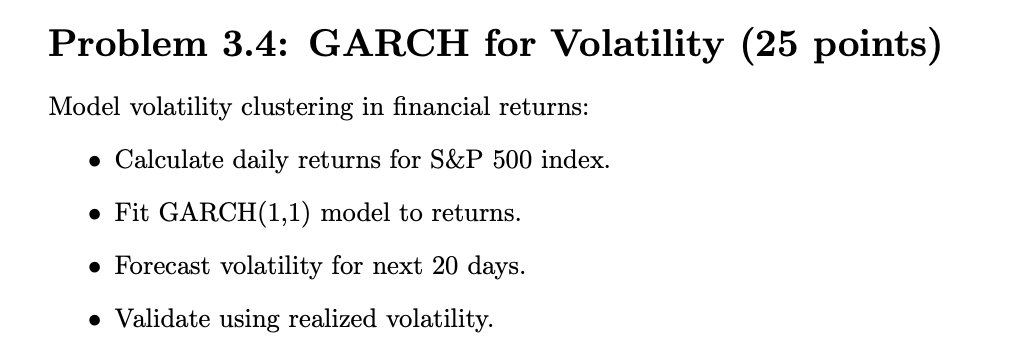

In [8]:
import yfinance as yf
import pandas as pd

# Download 10+ years of S&P 500 data (ticker: ^GSPC)
sp500 = yf.download('^GSPC', start='2014-01-01', end=None)
sp500.to_csv('sp500_10y.csv')  # Save to CSV if needed
sp500.info()

[*********************100%***********************]  1 of 1 completed

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3096 entries, 2014-01-02 to 2026-04-24
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   (Close, ^GSPC)   3096 non-null   float64
 1   (High, ^GSPC)    3096 non-null   float64
 2   (Low, ^GSPC)     3096 non-null   float64
 3   (Open, ^GSPC)    3096 non-null   float64
 4   (Volume, ^GSPC)  3096 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 145.1 KB


In [126]:
df_all = pd.read_csv("/Users/marysia/Desktop/applied/ml/apl_math/sp500_10y.csv", index_col=0, parse_dates=True)
df = df_all[['Close']]
df['ret'] = 100 * np.log(df['Close']/df['Close'].shift(1))
train, test = df[:-20], df[-20:]

/var/folders/7f/qnqr5kmj7z9b_f11s8sp00v80000gn/T/ipykernel_37790/3810816034.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['ret'] = 100 * np.log(df['Close']/df['Close'].shift(1))


Text(0.5, 1.0, 'Returns - train set')

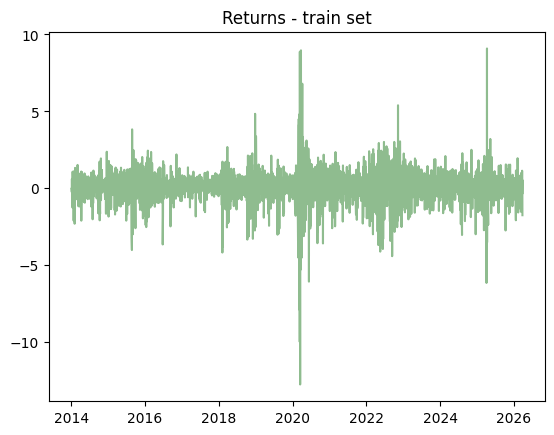

In [127]:
plt.plot(train["ret"], color = 'darkseagreen')
plt.title('Returns - train set')

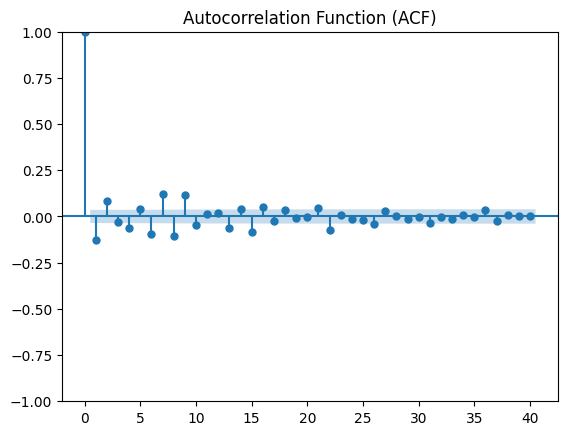

In [33]:
plot_acf(train['ret'].dropna(), lags=40)
plt.title('Autocorrelation Function (ACF)')
plt.show()

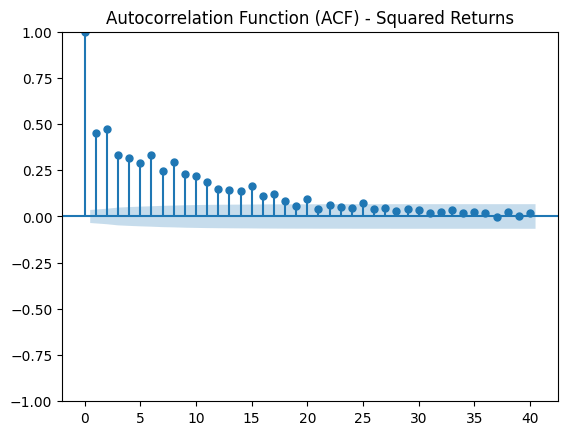

In [116]:
plot_acf(train['ret'].dropna()**2, lags=40)
plt.title('Autocorrelation Function (ACF) - Squared Returns')
plt.show()

In [115]:
model = arch.arch_model(train['ret'][1:], vol="Garch", p=1, q=1, mean="Constant", dist="Normal").fit()
model

Iteration:      1,   Func. Count:      6,   Neg. LLF: 59985573235223.09
Iteration:      2,   Func. Count:     15,   Neg. LLF: 1690419199.13022
Iteration:      3,   Func. Count:     22,   Neg. LLF: 5094.697416323366
Iteration:      4,   Func. Count:     28,   Neg. LLF: 4585.281406384339
Iteration:      5,   Func. Count:     35,   Neg. LLF: 6586.191478900551
Iteration:      6,   Func. Count:     41,   Neg. LLF: 3906.943311390041
Iteration:      7,   Func. Count:     46,   Neg. LLF: 3906.8001227222185
Iteration:      8,   Func. Count:     51,   Neg. LLF: 3906.787782190003
Iteration:      9,   Func. Count:     56,   Neg. LLF: 3906.787690402715
Iteration:     10,   Func. Count:     61,   Neg. LLF: 3906.787688254366
Iteration:     11,   Func. Count:     65,   Neg. LLF: 3906.787688254666
Optimization terminated successfully    (Exit mode 0)
            Current function value: 3906.787688254366
            Iterations: 11
            Function evaluations: 65
            Gradient evaluations: 11

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                    ret   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -3906.79
Distribution:                  Normal   AIC:                           7821.58
Method:            Maximum Likelihood   BIC:                           7845.70
                                        No. Observations:                 3075
Date:                Sat, Apr 25 2026   Df Residuals:                     3074
Time:                        15:21:39   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.0745  1.331e-02      5.601  2.129e-08 [4.846e-0

In [129]:
train = train.copy()
train['sigma'] = model.conditional_volatility
omega = model.params['omega']
alpha = model.params['alpha[1]']
beta = model.params['beta[1]']
resid = model.resid
mean = model.params['mu']
sigmas = [model.conditional_volatility[0]]
for t in range(1, len(resid)):
    sigma2 = omega + alpha * resid[t-1]**2 + beta * sigmas[-1]**2
    sigmas.append(np.sqrt(sigma2))

train['sigma_manual'] = [None]+sigmas

/var/folders/7f/qnqr5kmj7z9b_f11s8sp00v80000gn/T/ipykernel_37790/1929151380.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sigmas = [model.conditional_volatility[0]]
/var/folders/7f/qnqr5kmj7z9b_f11s8sp00v80000gn/T/ipykernel_37790/1929151380.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sigma2 = omega + alpha * resid[t-1]**2 + beta * sigmas[-1]**2


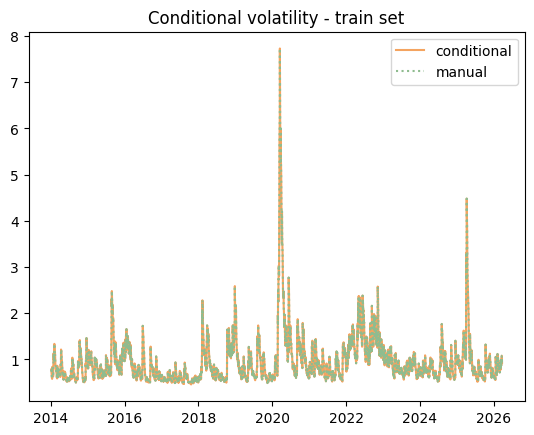

In [130]:
plt.plot(train['sigma'], color='sandybrown', label="conditional")
plt.plot(train['sigma_manual'], label="manual", ls=':', color = 'darkseagreen')
plt.title("Conditional volatility - train set");plt.legend()

In [131]:
train['std_ret'] = (train['ret'] - mean) / train['sigma']

Text(0.5, 1.0, 'Standarized returns - train set')

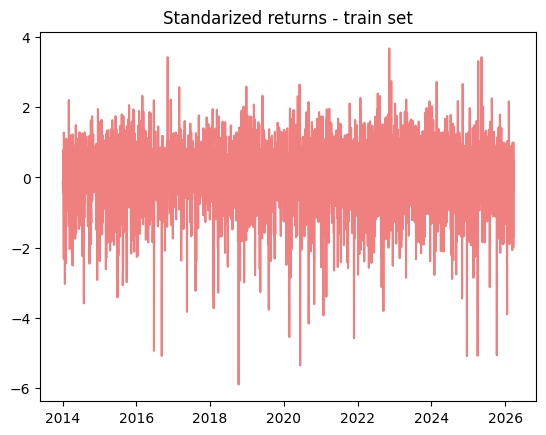

In [132]:
plt.plot(train['std_ret'], color='lightcoral');plt.title("Standarized returns - train set")

In [133]:
Z = np.random.normal(0,1,len(train))
train['test'] = Z

Text(0.5, 1.0, 'Standarized returns vs N(0,1) - train set')

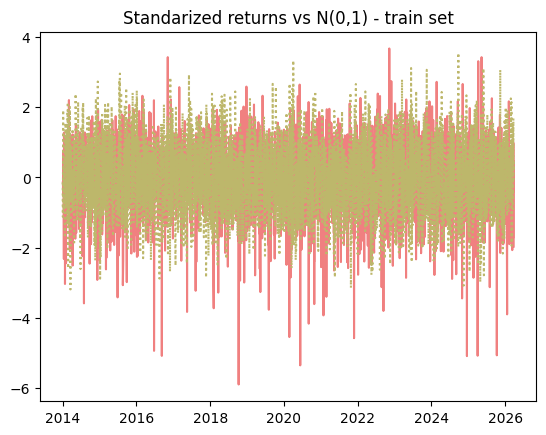

In [134]:
plt.plot(train['std_ret'], color='lightcoral', label = 'Std returns')
plt.plot(train['test'], color='darkkhaki', ls=':', label = 'N(0,1)')
plt.title("Standarized returns vs N(0,1) - train set")

In [135]:
from scipy.stats import shapiro, jarque_bera

# Shapiro-Wilk test
stat, p = shapiro(train['std_ret'].dropna())
print(f"Shapiro-Wilk test: statistic={stat:.4f}, p-value={p:.4f}")

# Jarque-Bera test
jb_stat, jb_p = jarque_bera(train['std_ret'].dropna())
print(f"Jarque-Bera test: statistic={jb_stat:.4f}, p-value={jb_p:.4f}")

Shapiro-Wilk test: statistic=0.9687, p-value=0.0000
Jarque-Bera test: statistic=995.0465, p-value=0.0000


In [136]:
forecast = model.forecast(horizon=20)
forecast_vol = np.sqrt(forecast.variance)
realized_vol = train['ret'].rolling(window=20).std()

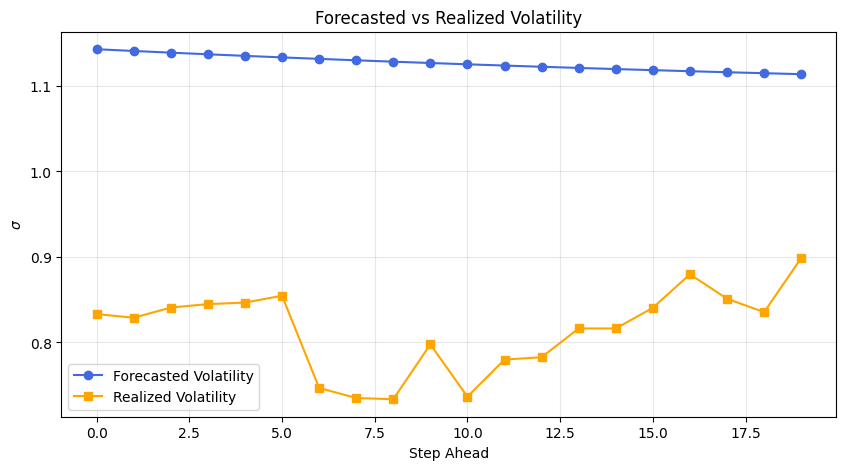

In [137]:
plt.figure(figsize=(10, 5))
plt.plot(forecast_vol.values[-1], marker='o', color='royalblue', label='Forecasted Volatility')
plt.plot(realized_vol[-20:].values, marker='s', color='orange', label='Realized Volatility')
plt.title('Forecasted vs Realized Volatility')
plt.xlabel('Step Ahead')
plt.ylabel(r'$\sigma$')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [138]:
def garman_klass(df):
    log_hl = np.log(df['High'] / df['Low'])
    log_co = np.log(df['Close'] / df['Open'])
    variance = 0.5*(log_hl ** 2) - (2 * np.log(2) - 1) * (log_co ** 2)
    return np.sqrt(variance)*100

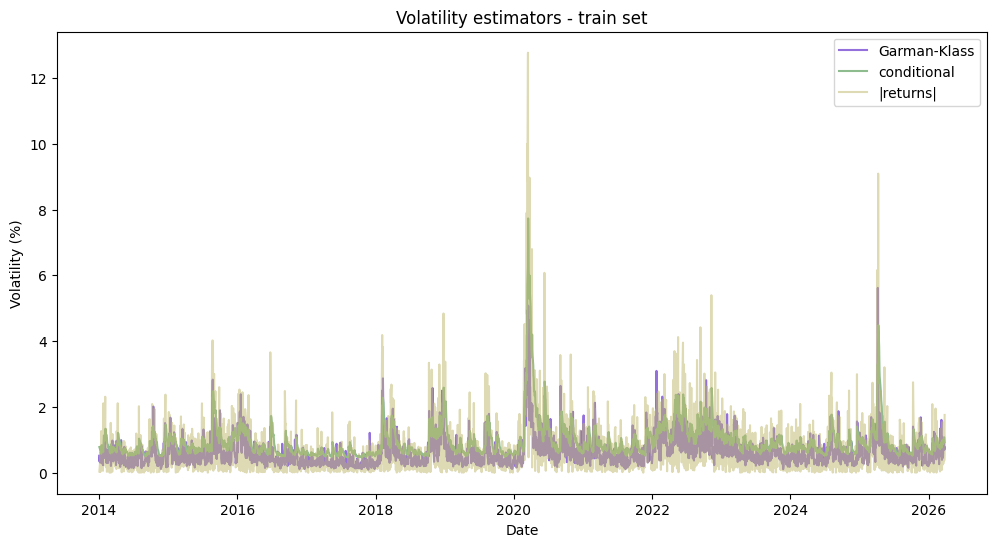

In [145]:
GK = garman_klass(df_all)
plt.figure(figsize=(12, 6))
plt.plot(GK[:-20], color='mediumpurple', label = 'Garman-Klass')
plt.plot(train['sigma'], label="conditional", color = 'darkseagreen')
plt.plot(np.abs(train['ret']), color='darkkhaki', label="|returns|", alpha=0.5)
plt.title('Volatility estimators - train set')
plt.xlabel('Date')
plt.ylabel('Volatility (%)')
plt.legend()
plt.show()